# CS103 Elements of AI assignment2

Read the homework description carefully and follow the instructions. Please be fully aware that this homework is an individual task; you can discuss the problem with your friends, but
you must not implement your idea together. You will fail the entire course (that is, your CS103 grade will be an F) if you are found to be involved in any attempt of plagiarism.

## Guideline
Primary TA: Sihwa Lee(dltlghk5571@kaist.ac.kr)

**How to submit**

* Follow instructions of 🛑 <mark> TODO</mark> blocks. DO NOT modify other parts of the code.
* Submit the folder which contains assignment2 in Jupyter Notebook.
* Due date: 23:59:59 **Mar 19th** (Thr). Late submission accepted until 23:59:59 **Mar 21th** (Sat) with 20% penalty.
* Before submitting, please make sure that you did all the 🛑<mark>TODO</mark>s.

**Important notes**
*   Before submission, check that all cells can be executed sequentially by restarting runtime and running all.
* We will test the correctness of your implementation to score each of the 🛑 <mark> TODO</mark>.

Please feel free to ask questions on KLMS Q&A board with title ```[assignment2]``` in front.

## Introduction

In Assignment 1, we built a spam filter using a rule-based approach. The system classified messages based on manually defined keywords.

This approach works—but only as long as we can anticipate every possible spam word.
If a new word appears that was not in our glossary, the filter fails.

Humans must define all rules in advance.



### Moving to a Representation-Based Approach
Words with similar meanings appear in similar contexts. Instead of relying on manually written rules, why dont' we focus on the structure of language itself?

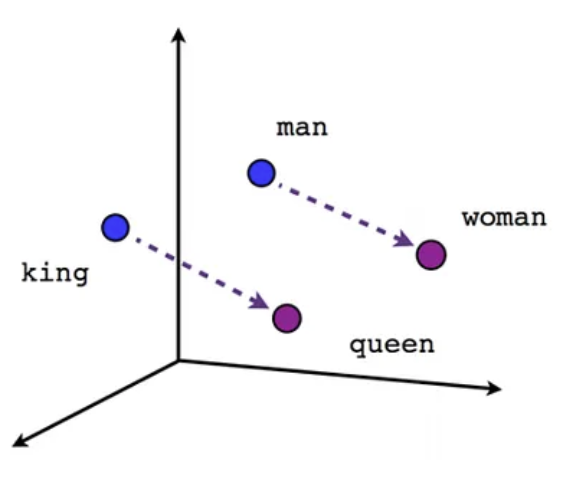

As you can see in this image, similar words are located near each other. Once our sentences are represented as vectors, we can measure:

* Distance
* Angle
* Similarity

Between each sentences, instead of checking rules individually. Then, our task becomes a geometric problem.



### Overview
In this assignment, you will implement a spam filtering system from scratch, exploring:

* Vector Calculation
* Bag of Words (BoW)
* Euclidean Distance
* Cosine Similarity
* Rocchio Classification
* K-Nearest Neighbors (KNN)
* TF-IDF Vectorization

You will observe how:

* Different vectorization methods
* Different similarity metrics
* Different classification algorithms

You will implement the following:
* 🛑 <mark> TODO 0</mark>: Implement the `dot_product` and `norm` function
* 🛑 <mark> TODO 1</mark>: Create the vocabulary for BoW
* 🛑 <mark> TODO 2</mark>: Vectorize the sentences with BoW
* 🛑 <mark> TODO 3</mark>: Measure the Euclidean distance
* 🛑 <mark> TODO 4</mark>: Implement cosine_similarity()
* 🛑 <mark> TODO 5</mark>: Calculate Class Centroid
* 🛑 <mark> TODO 6</mark>: Implement Rocchio Classification
* 🛑 <mark> TODO 7</mark>: Implement k-Nearest Neighbors
* 🛑 <mark> TODO 8</mark>: Hyperparameter Tuning
* 🛑 <mark> TODO 9</mark>: Implementing TF-IDF (Term Frequency-Inverse Document Frequency)

# 0. Essentials

In this section, we are doing the following:

* Installing and importing the required **package**
* Loading the **dataset**

### Import Libraries ###

The following code imports the libraries needed for this assignments:

- **`pandas` (abbreviated as `pd`)**: A library for data analysis. It specializes in handling tabular data and provides functions for reading CSV files, filtering data, grouping, and more.
- **`re`**: A module for using regular expressions. It is used to find or transform specific patterns in text data.
- **`numpy` (abbreviated as `np`)**: A core library for numerical computations. It provides array operations, linear algebra, statistical functions, and more. It allows us to:

  - Create vectors (arrays)
  - Perform vector arithmetic
  - Compute distance and similarity

In [2]:
# Pandas: library for data analysis and processing
# Using pd.read_csv(), you can read CSV files and convert them into DataFrames
import pandas as pd

# Regular expression module: used for text pattern matching
import re

# NumPy: library for numerical computations and array processing
# Using np.array(), you can convert a list into a numpy array
import numpy as np


### Load and preprocess datasets

We first mount Google Drive to access the dataset file.

We load the spam dataset, clean the text, and convert labels into numerical format.

In [3]:
# Load CSV file
# If you are unavailable to load the data file, please contact TA.
df = pd.read_csv('./data.csv', encoding='latin1')

texts = df['text'].tolist()
labels = np.array(df['label'].tolist())

df.head()


,Unnamed: 0,label,text
0,0,0,alex i agree let them make up the data pleas...
1,1,1,hey save a bundle on offshore drugs shipped di...
2,2,1,while we may have high expectations of our ass...
3,3,0,alek storm via rt wrote the following code dem...
4,4,1,he felt tiny hard goosebumps rising on his ski...


#1. Introduction to vector calculation using numpy

In this assignment we are going to make an sentence in to vector and calculate the vector.
Numpy is a library designed for easy and fast manipulation of numerical data in arrays, which consist of elements of the same type. Unlike standard Python lists that focus on flexibility (such as storing strings or mixed types), Numpy arrays are optimized for performance.

You can create a Numpy array using the following method:
```python
arr = np.array(list)
```
To create an array of size N consisting only of zeros:
```python
empty_arr = np.zeros(N)
```
The dot product of two vectors is calculated as follows. Here, the dot product is an operation that multiplies two vectors of the same dimension to derive a scalar value. This is done by multiplying the corresponding components of the two vectors and then summing them up.

Example: If you take the dot product of $[x_1, x_2, x_3]$and $[y_1, y_2, y_3]$, the value is:
$$ [x_1, x_2, x_3] \cdot [y_1, y_2, y_3] = x_1\times y_1 + x_2\times y_2 + x_3\times y_3 $$
This is an important means of representing a vector as a scalar. The vector product (dot product) is used as follows:
```python
dot_prod = np.dot(vec_A, vec_B)
```
The magnitude (or length) of a high-dimensional vector is called the "norm." In 2D space, this is simply the length you already know from geometry. The norm of a vector can be obtained as follows:
```python
norm = np.linalg.norm(vec_A)
```
To find the indices of a vector's values in ascending order (useful for finding the positions of top values):
```python
index = np.argsort(vec_A)
```

You are required to write your code following the 🛑 <mark>TODO</mark> indicators. Please read the instructions carefully before you start. Ensure that your code is written **only** within the `<TODO>` and `</TODO>` blocks; do not modify any other parts of the script.

Additionally, 🛑 <mark> TODO 0</mark> will not be scored but is required for the following code.

---
#### 🛑 <mark> TODO 0</mark>: Implement the `dot_product` and `norm` function.
* Calculate the dot product of two vector
* Calculate the norm of two vector

In [4]:
def dot_product(vec_A, vec_B):
    """
    Calculate the dot product of two vectors.

    Args:
        vec_A (np.ndarray): First input vector.
        vec_B (np.ndarray): Second input vector.

    Returns:
        float: The resulting dot product value.
    """
    # =============================================================
    # TODO 0-(a): Vector Operations using Numpy
    # 1. Calculate the dot product of vec_A and vec_B using np.dot().
    # =============================================================
    # <TODO>
    # YOUR CODE HERE
    dot_prod=np.dot(vec_A, vec_B)
    # </TODO>
    return dot_prod

def norm(vec):
    """
    Calculate the norm (magnitude) of a vector.

    Args:
        vec (np.array): The input vector.

    Returns:
        float: The L2 norm of the vector.
    """
    # =============================================================
    # TODO 0-(b): Vector Operations using Numpy
    # 1. Calculate the length (norm) of vec using np.linalg.norm().
    # =============================================================
    # <TODO>
    # YOUR CODE HERE
    norm=np.linalg.norm(vec)
    # </TODO>
    return norm

Now, let's test our functions with simple example vectors to ensure that the dot product and norm are calculated correctly.

In [5]:
vec_A = np.array([3, 4])
vec_B = np.array([6, 8])
print(f"Vector A: {vec_A}")
print(f"Vector B: {vec_B}")
dot_prod = dot_product(vec_A, vec_B)
print(f"Dot Product: {dot_prod}")
norm_A = norm(vec_A)
norm_B = norm(vec_B)
print(f"Length of Vector A: {norm_A}")
print(f"Length of Vector B: {norm_B}")

Vector A: [3 4]
Vector B: [6 8]
Dot Product: 50
Length of Vector A: 5.0
Length of Vector B: 10.0


Additionally, to improve efficiency, we can replace nested for loops with Vectorized Matrix Operations when calculating dot products.

Imagine we want to measure how much fruit preferences overlap between Alice, Bob, and Charlie. We represent their preferences as vectors:
```python
import numpy as np

# Preference data for [Alice, Bob, Charlie]
# 1 indicates liking a fruit, 0 indicates otherwise
preferences = np.array([
    [1, 0, 1], # Alice
    [0, 1, 1], # Bob
    [1, 1, 0]  # Charlie
])

# Standard approach using nested loops
similarity_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        # Calculating the dot product for each pair individually
        similarity_matrix[i, j] = np.dot(preferences[i], preferences[j])

```
While this logic is easy to follow, it is highly inefficient. The reason is because it calculates each dot product *sequentially* using the nested `for` loop.
As your dataset grows, the number of iterations increases quadratically, leading to significant performance bottlenecks because Python loops are relatively slow.

So, we can achieve the same result instantly by treating the entire collection of preferences as a single matrix $A$. By multiplying the matrix by its own transpose ($A^T$), we calculate the dot product for every possible pair *in parallel*.
```python
# The highly efficient NumPy way
similarity_matrix = np.matmul(A, A.T)

# Or alternatively:
# similarity_matrix = A @ A.T
```
Multiplying the matrix allows NumPy to compute all relationships simultaneously in optimized C-code, bypassing the slow overhead of Python's individual loop iterations.

Please keep in mind that the nested `for` loop approach is expected to be very slow. As your dataset grows, the execution time for the loops will increase quadratically, making it impractical for real-world data.

In [6]:
import numpy as np
import time

# 500 sentences, 500 features (Randomly generated)
N, D = 500, 500
show_matrix_multi_data = np.random.rand(N, D)

# --- Method 1: Python Triple Nested Loop ---
print(f"Data size: {N}x{D} | Starting similarity calculation...")
start = time.time()
loop_sim = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        s = 0
        for k in range(D): # Manual dot product loop
            s += show_matrix_multi_data[i, k] * show_matrix_multi_data[j, k]
        loop_sim[i, j] = s
loop_time = time.time() - start

# --- Method 2: NumPy Matrix Operation (@) ---
start = time.time()
# The np.matmul operator or '@' performs the dot product for all pairs at once
numpy_sim = np.matmul(show_matrix_multi_data, show_matrix_multi_data.T)
numpy_time = time.time() - start

print(f"\n[Performance Results]")
print(f"1. Loop Method Time  : {loop_time:.4f} seconds")
print(f"2. NumPy Method Time : {numpy_time:.4f} seconds")
print(f"NumPy is approximately {int(loop_time / numpy_time):,}x faster!")

Data size: 500x500 | Starting similarity calculation...

[Performance Results]
1. Loop Method Time  : 25.1266 seconds
2. NumPy Method Time : 0.0021 seconds
NumPy is approximately 12,243x faster!


# 2. Vectorization - Bag of Words
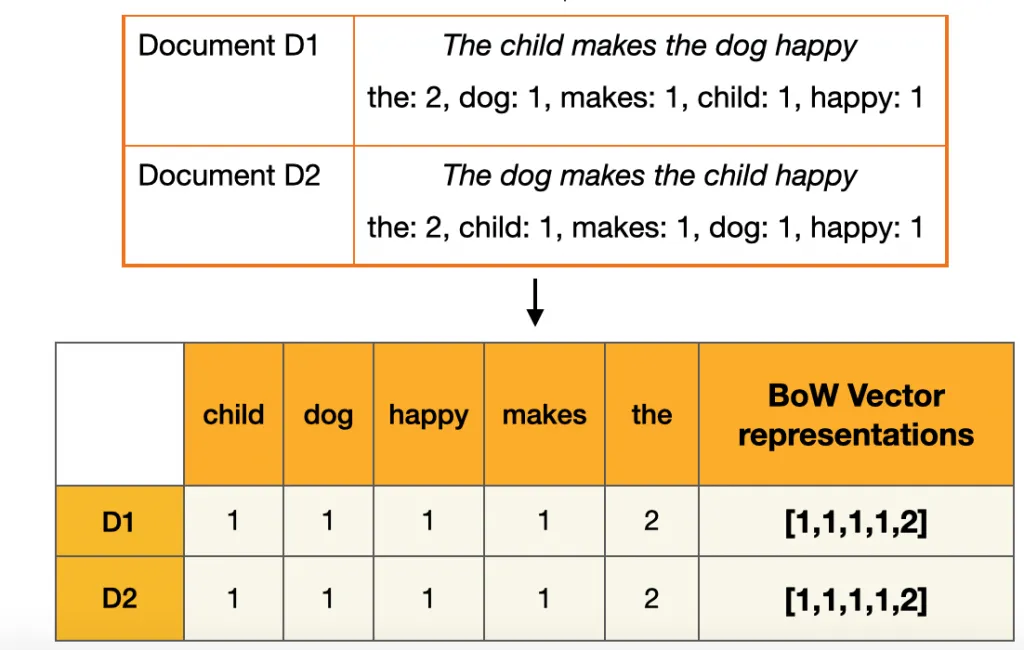
**Bag of Words (BoW)** is one of the simplest ways to convert a sentence into a vector.
The idea is straightforward:

* First, build a vocabulary (vocab) from the dataset (all unique words).
* Then, represent each sentence as a vector of length |vocab|.
* Each entry in the vector is the count of **how many times that word appears** in the sentence.

BoW ignores word order and grammar — it only “counts words”.
This makes BoW very naive, but also very easy to implement.

---
#### 🛑 <mark> TODO 1</mark>: Create the vocabulary for BoW

To build BoW vectors, we first need a shared vocabulary.

In this TODO, you will implement `get_vocab(texts)`:
* Combine all sentences in texts
* Split them into tokens (words)
* Remove duplicates
  * Note: you should distinguish the capitalized words (Apple and apple are diffferent).
* Sort the final vocabulary in **alphabetical order**

This vocabulary will be used in later steps to decide:
* the dimension of our BoW vectors
* the index of each word in the vector

In [9]:
def get_vocab(texts):
    """
    Builds a sorted vocabulary of unique words from the provided list of texts.

    Args:
        texts (list[str]): A list of sentences or messages to process.

    Returns:
        list[str]: A list of unique words (tokens) sorted in alphabetical order.
    """
    # =============================================================
    # TODO 1: Building the Vocabulary
    # 1. Combine all sentences in the 'text' list into a single string.
    # 2. Split the string into individual words (tokens).
    # 3. Use set() to remove redundant words and keep only unique tokens.
    # 4. Sort the unique words in alphabetical order and store them in 'vocab'.
    # =============================================================
    # <TODO>
    # YOUR CODE HERE
    unqword=set()
    for text in texts:
        tokens=text.split()
        for token in tokens:
            unqword.add(token)

    vocab=sorted(list(unqword))
    
    # </TODO>
    return vocab

In [10]:
vocab = get_vocab(texts)

In [11]:
# Scoring section

assert get_vocab(["apple banana", "banana cherry"]) == ['apple', 'banana', 'cherry'], "Check sorting and unique values"
assert get_vocab(["data science", "machine learning"]) == ['data', 'learning', 'machine', 'science'], "Check alphabetical order"
# Hidden test results are hidden to ensure evaluation integrity.




#### 🛑 <mark> TODO 2</mark>: Vectorize the sentences with BoW

Now that we have constructed the vocabulary (Vocab, which defines our vector space),
we are ready to convert each sentence into a numerical vector.

In this TODO, you will implement `get_bag_of_words(text,vocab)`.
Each sentence will be represented as a vector of length equal to the dimension of Vocab.
For every word in the vocabulary:

* If the word appears in the sentence → we count its frequency
* If the word does not appear → the value is 0

This transforms a sentence from a string into a fixed-length numerical vector.



For example, suppose:

```python
vocab = ["a", "cat", "dog", "happy", "is"]
text  = "a happy dog is happy"
```

Then the resulting Bag of Words vector will be:

```python
[1, 0, 1, 2, 1]
```

In [14]:
def get_bag_of_words(text,vocab):
    """
    Converts a given text into a Bag of Words (BoW) vector based on a provided vocabulary.

    Args:
        text (str): The input sentence to be vectorized.
        vocab (list[str]): A list of unique words representing the vocabulary.

    Returns:
        list[int]: A frequency vector where each element corresponds to the count
                   of a vocabulary word in the input text.
    """
    # =============================================================
    # TODO 2: Implementing Bag of Words (BoW)
    # 1. Tokenize the input 'text' by splitting it into individual words.
    # 2. Iterate through each word in the 'vocab'.
    # 3. For each word, count how many times it appears in the tokenized text.
    # 4. Append each frequency count to 'bow_vec' to create the final vector.
    # =============================================================

    bow_vec = []
    # <TODO>
    # YOUR CODE HERE
    vec=np.zeros(len(vocab))
    words=text.split()
    for word in words:
        idx=vocab.index(word)
        vec[idx]+=1
    # </TODO>
    return bow_vec

In [15]:
# Scoring section

vocab_basic = ['apple', 'banana', 'cherry']
assert get_bag_of_words("apple banana apple", vocab_basic) == [2, 1, 0], "Check word counts and order"
assert get_bag_of_words("cherry cherry cherry", vocab_basic) == [0, 0, 3], "Check mapping to the last element"
assert get_bag_of_words("unknown word test", vocab_basic) == [0, 0, 0], "Words not in vocab should be ignored"

# Hidden test results are hidden to ensure evaluation integrity.



IndexError: list index out of range

# 3. Distance Metric
Now that we have represented sentences as vectors (points in a high-dimensional space),
we need a way to measure how similar they are.

Since vectorization converts textual features into numerical values,
sentences with similar word distributions should be located near each other in vector space.

To quantify similarity, we measure the distance between two vectors.
One natural way is to use the **Euclidean Distance**.

## 3.1. Euclidean Distance
Euclidean distance represents the straight-line distance between two points.

It is a direct extension of the Pythagorean theorem from 2D and 3D space
to an N-dimensional space.

* Mathematical Definition

Given two vectors $A$and $B$, we compute the difference in each dimension, square them, sum them,
and finally take the square root($\sqrt{\phantom{x}}$).

$$\text{Euclidean Distance}(A, B) = \sqrt{ (A_1 - B_1)^2 + (A_2 - B_2)^2 + \dots + (A_n - B_n)^2 }$$

* Interpretation

If the distance is close to $0$, the two vectors are almost identical.
If the distance is large, the two vectors are far apart (less similar).


---

#### 🛑 <mark> TODO 3</mark>: Measure the Euclidean distance.

Now, implement a function that computes the Euclidean distance between two vectors.

Recall:

* Subtract the two vectors
* Compute the norm (magnitude) of the difference

This gives the geometric distance between two points in vector space.

In [ ]:
def get_euclidean_distance(v1, v2):
    """
    Calculates the Euclidean distance between two vectors.

    Args:
        v1 (np.ndarray): The first feature vector.
        v2 (np.ndarray): The second feature vector.

    Returns:
        float: The L2 norm (straight-line distance) between v1 and v2.
    """
    # =============================================================
    # TODO 3: Calculating Euclidean Distance
    # 1. Understand that Euclidean distance represents the straight-line distance between two points.
    # 2. Use np.linalg.norm() to calculate the magnitude of the difference between vectors v1 and v2.
    # Note: Ensure the function returns a scalar value representing the geometric distance.
    # =============================================================
    magnitude = 0.0
    # <TODO>
    # YOUR CODE HERE
    magnitude = np.linalg.norm(v1 - v2)
    # </TODO>
    return magnitude

In [ ]:
# Scoring section
v_a = np.array([1, 0])
v_b = np.array([4, 0])
assert np.isclose(get_euclidean_distance(v_a, v_b), 3.0), "Check simple 1D distance"

v_c = np.array([0, 0])
v_d = np.array([3, 4])
assert np.isclose(get_euclidean_distance(v_c, v_d), 5.0), "Check 2D distance (Pythagorean)"

# Hidden test results are hidden to ensure evaluation integrity.



## 3.2 cosine similarity

### 3.2.0. Limitation of Euclidean Distance

In Bag of Words representation,
each word’s frequency directly affects the magnitude of the vector.

If a word appears many times,
the corresponding dimension grows larger.

Since Euclidean distance depends on the magnitude of vectors, it may consider a longer sentence (with repeated words) to be far away; even if it shares the same meaning.

---
For example, suppose we have the following three sentences:

```python
data = [
    "I am doing my CS103 homework",
    "When I took CS103 last semester the professor lectures were excellent and the CS103 TAs were very kind",
    "I am a cat"
]
```

Then the resulting Bag of Words vector will be:

```python
vectors = [
  [0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 0, 2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 2, 1],
  [1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]
```

Even though Sentence 1 and Sentence 2 shares the same topic, Euclidian distance suggests:
```python
Distance(Sentence 1, Sentence 2) ≈ 4.90
Distance(Sentence 1, Sentence 3) ≈ 2.45
```

In [ ]:
test_data = ['bag', 'bag bag bag', 'word']
vocab_of_test_data = sorted(list(set(" ".join(test_data).split())))

vec_0 = np.array(get_bag_of_words(test_data[0], vocab_of_test_data))
vec_1 = np.array(get_bag_of_words(test_data[1], vocab_of_test_data))
vec_2 = np.array(get_bag_of_words(test_data[2], vocab_of_test_data))

dist_1 = get_euclidean_distance(vec_0, vec_1)
dist_2 = get_euclidean_distance(vec_0, vec_2)

print(f"dist_1 bag <-> bag bag bag: {dist_1:.3f}")
print(f"dist_2 bag <-> word: {dist_2:.3f}")

if dist_1 > dist_2:
    print("\n[Analysis]: Limitation Confirmed!")
    print(f"The distance between same-meaning sentences is LARGER than different ones.")
    print("Reason: Euclidean distance is too sensitive to word frequency (magnitude).")

### 3.2.1. cosine similarity

Euclidean distance is sensitive to vector magnitude.
To overcome this limitation, we measure similarity using angle instead of distance.

Cosine similarity measures the cosine of the angle 𝜃 between two vectors 𝐴 and 𝐵.

Rather than asking:
> “How far apart are they?”  

We ask:
>“Are they pointing in the same direction?”

---

Mathematical Definition
$$\text{Cosine Similarity}(A, B) = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$$

* $A \cdot B$ : **Dot Product** between two vectors
* $\|A\| \|B\|$ : Product of **vector magnitudes (Norm)**


When working with text data (BoW or TF-IDF), vector elements are typically **non-negative**.

Therefore, cosine similarity usually ranges between:
* 1.0 → Perfectly aligned (very similar)
* 0.0 → Orthogonal (completely unrelated)

---
#### 🛑 <mark> TODO 4</mark>: Implement cosine_similarity()
Now, implement the cosine similarity function.

Your task is to:

* Compute the dot product of the two vectors.
* Compute the norm of each vector.
* Divide the dot product by the product of the norms.

This function will allow us to compare sentences
based on direction rather than distance.

>  **Note:**  
> Be careful with the **zero-vector case**.  
> If either vector has a norm of `0`,  
> you must return `0.0` to avoid division by zero.

In [ ]:
def cosine_similarity(v1, v2):
    """
    Calculates the Cosine Similarity between two vectors.

    Args:
        v1 (np.ndarray): The first feature vector.
        v2 (np.ndarray): The second feature vector.

    Returns:
        float: Cosine similarity between v1 and v2, ranging from -1 to 1.
               Returns 0.0 if either vector has a magnitude of zero.
    """
    # Calculate the Cosine Similarity.
    # Hint : Handle the division by zero case. (if a norm is 0, return 0.0)
    # =============================================================
    # TODO 4: Calculating Cosine Similarity
    # 1. Compute the dot product of vectors v1 and v2 using np.dot().
    # 2. Calculate the L2 norm (magnitude) of each vector using np.linalg.norm().
    # Note. Check for the division by zero case: if either norm is 0, return 0.0.
    # 3. Calculate the similarity using the formula: dot_product / (norm1 * norm2).
    # =============================================================
    similarity = 0.0
    # <TODO>
    # YOUR CODE HERE
    raise NotImplementedError()
    # </TODO>
    return similarity

In [ ]:
# Scoring section

v_a = np.array([1, 1, 1])
v_b = np.array([2, 2, 2])
assert np.isclose(cosine_similarity(v_a, v_b), 1.0), "Same direction vectors should have similarity 1.0"

v_zero = np.array([0, 0, 0])
assert cosine_similarity(v_zero, v_a) == 0.0, "Should return 0.0 if a vector is zero"

v_ortho1 = np.array([1, 0])
v_ortho2 = np.array([0, 1])
assert np.isclose(cosine_similarity(v_ortho1, v_ortho2), 0.0), "Orthogonal vectors should have similarity 0.0"

# Hidden test results are hidden to ensure evaluation integrity.



# 4. Algorithm

Now that we have represented sentences as vectors and defined distance/similarity metrics,  
we are finally ready to perform classification.


Then, how do we decide whether a sentence is spam or not?  
We need a reference representation for each class (spam or not).

## 4.1 Rocchio Algorithm (Centroid-Based Classification)

One simple way to classify vectors is to compute the **centroid** of each class.

A centroid is the average of all vectors belonging to a class.

When a new sentence is given with the existing centroids:

- Compute the vector of a new sentence.
- Measure its distance (or similarity) to each class centroid.
- Assign it to the closest one.

This method is known as the **Nearest Centroid Classifier**.

In text classification with vector representations,  
this approach is commonly referred to as the **Rocchio Algorithm**.


---
#### 🛑 <mark> TODO 5</mark>: Calculate Class Centroid
First, we must compute the centroid for each class.

Your task is to:

* Separate training vectors based on their labels (Ham vs Spam).
* Compute the mean vector for each group.
* Return the two centroids.

These centroids represent the "average spam message" and the "average ham message" in vector space.

In [ ]:
train_vectors = []
# Below loop takes about 3 minutes.
for t in texts:
    vector = get_bag_of_words(t, vocab)
    train_vectors.append(vector)

In [ ]:
def get_centroids(train_vectors, train_labels):
    """
    Computes the average vector (centroid) for each class to represent its central tendency.

    Args:
        train_vectors (np.ndarray): A 2D array where each row is a BoW vector of a training sentence.
        train_labels (np.ndarray): A 1D array of labels (0 for Ham, 1 for Spam).

    Returns:
        tuple[np.ndarray, np.ndarray]: A tuple containing:
            - centroid_ham: The mean vector representing the 'Ham' class.
            - centroid_spam: The mean vector representing the 'Spam' class.
    """
    # =============================================================
    # TODO 5: Calculating Class Centroids (Rocchio Training)
    # 1. Separate 'train_vectors' into two groups based on 'train_labels' (Ham and Spam).
    # 2. Calculate the mean vector (Centroid) for each group using np.mean(axis=0).
    # 3. These centroids represent the "average" message for each class in the vector space.
    # =============================================================
    # <TODO>
    # YOUR CODE HERE
    raise NotImplementedError()
    # </TODO>
    return centroid_ham, centroid_spam

In [ ]:
# Scoring section

train_vecs = np.array([[1, 1], [3, 3], [10, 10], [20, 20]])
train_labs = np.array([0, 0, 1, 1])
c_ham, c_spam = get_centroids(train_vecs, train_labs)

assert np.allclose(c_ham, [2.0, 2.0]), "Check Ham centroid (mean of [1,1] and [3,3])"
assert np.allclose(c_spam, [15.0, 15.0]), "Check Spam centroid (mean of [10,10] and [20,20])"

# Hidden test results are hidden to ensure evaluation integrity.



Now that we have computed the centroid of each class,
we can implement the Rocchio classification algorithm:

- Represent each test sentence as a vector.
- Compare it to the centroid of each class.
- Assign the label of the closer (or more similar) centroid.

In vector space, classification becomes a geometric comparison.

---
#### 🛑 <mark> TODO 6</mark>: Implement Rocchio Classification

Using the centroids computed earlier,
implement the Rocchio classification logic.

Your task is to:

* Obtain the centroids of Ham and Spam.
* For each test vector:
   - Compute the **cosine similarity** to both centroids.
*  Assign the label of the more similar class.
*  Return the predictions as a NumPy array.

In [ ]:
def rocchio_classifier(test_vectors, labels):
    """
    Predicts labels for test vectors by comparing them to class centroids.

    Args:
        test_vectors (np.ndarray): 2D array of BoW vectors to be classified.
        train_labels (np.ndarray): 1D array of ground-truth labels for training.

    Returns:
        np.ndarray: A 1D array of predicted labels (0 for Ham, 1 for Spam).
    """
    # =============================================================
    # TODO 6: Rocchio Classification Logic
    # 1. Get centroid_ham and centroid_spam
    # 2. Iterate 3-6 through each vector in 'test_vectors'.
    # 3. Calculate the cosine similarity between the current vector and 'centroid_ham'.
    # 4. Calculate the cosine similarity between the current vector and 'centroid_spam'.
    # 5. Predict '1' (Spam) if it is closer to the spam centroid, else '0' (Ham).
    # 6. Return the predictions as a Numpy array.
    # Note. if the similarity is same, then classify it as a ham.
    # =============================================================
    # <TODO>
    # YOUR CODE HERE
    raise NotImplementedError()
    # </TODO>

In [ ]:
# Scoring section

test_vecs = np.array([[1, 0.1], [0.1, 1]])
test_labels = np.array([0, 1])

preds = rocchio_classifier(test_vecs, test_labels)
assert np.array_equal(preds, [0, 1]), "Check if the classifier assigns the label of the closest centroid"

# Hidden test results are hidden to ensure evaluation integrity.



### Evaluate performance
Then, let's evaluate its performance.

We will compare the predicted labels with the ground truth labels
and compute standard classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

This allows us to quantitatively measure
how well our vector-based classifier performs.

In [ ]:
# we implement the function in assignment0
def get_tfpn(true_labels, pred_labels):
  """
  Counts the four outcomes of binary classification for model evaluation. (TP, TN, FP, FN)

  Definitions:
    - TP (True Positive): The model predicted 1, and the actual label was 1.
    - TN (True Negative): The model predicted 0, and the actual label was 0.
    - FP (False Positive): The model predicted 1, but the actual label was 0.
    - FN (False Negative): The model predicted 0, but the actual label was 1.

  Args:
    true_labels (list): A list of actual ground truth labels (0 or 1).
    pred_labels (list): A list of model-generated predictions (0 or 1).

  Returns:
    tuple: (tp, tn, fp, fn) as four separate integers.
  """
  tp = 0
  tn = 0
  fp = 0
  fn = 0

  for i in range(len(true_labels)):
    p = pred_labels[i]
    t = true_labels[i]

    if p == 1 and t == 1:
      tp = tp + 1
    elif p == 0 and t == 0:
      tn = tn + 1
    elif p == 1 and t == 0:
      fp = fp + 1
    elif p == 0 and t == 1:
      fn = fn + 1

  return tp, tn, fp, fn

def evaluate(true_labels, pred_labels):
  """
  Evaluate the performance of a binary classification model.

  Args:
    tp (int): True Positives (Actual: 1, Predicted: 1)
    tn (int): True Negatives (Actual: 0, Predicted: 0)
    fp (int): False Positives (Actual: 0, Predicted: 1)
    fn (int): False Negatives (Actual: 1, Predicted: 0)

  Returns:
    tuple: (accuracy, precision, recall, f1_score) as float values.
  """

  tp, tn, fp, fn = get_tfpn(true_labels, pred_labels)

  epsilon = 1e-9
  accuracy = (tp + tn) / (tp + tn + fp + fn + epsilon)
  precision = tp / (tp + fp + epsilon)
  recall = tp / (tp + fn + epsilon)
  f1_score = 2 * (precision * recall) / (precision + recall + epsilon)

  return accuracy, precision, recall, f1_score

In [ ]:
# Generate predictions using Rocchio classifier
preds = rocchio_classifier(np.array(train_vectors), np.array(labels))

# Evaluate predictions using standard classification metrics
accuracy, precision, recall, f1_score = evaluate(labels, preds)

# Print evaluation results
print(f"--- Rocchio Evaluation Results ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1_score:.4f}")

## 4.2. k-Nearest Neighbors

Unlike the Rocchio algorithm, which represents each class by a single centroid,
k-Nearest Neighbors (k-NN) is an instance-based classification method.

Instead of comparing a test sentence to a class average,
k-NN compares it directly to individual training examples.

The idea is simple:

For a given query,
- Find the k most closest training sentences,
- Assign the majority label among them.

This allows the model to consider local structure in the data,
rather than relying on a global average.

---
#### 🛑 <mark> TODO 7</mark>: Implement k-Nearest Neighbors

In this section, implement the KNN classifier using Cosine Similarity.

Your task is to:

1. Normalize all vectors to unit length.
2. Compute pairwise cosine similarity.
3. For each vector, find the top-k most similar neighbors
   (excluding itself).
4. Predict the label using majority voting.

In [ ]:
def knn_classifier(train_vectors, train_labels, k):
    """
    Predicts labels using K-Nearest Neighbors (K-NN) with Cosine Similarity.

    Args:
        train_vectors (np.ndarray): 2D array of training BoW vectors.
        train_labels (np.ndarray): 1D array of labels for the training vectors.
        k (int): Number of nearest neighbors to consider.

    Returns:
        np.ndarray: Predicted labels for the input vectors.
    """
    # =============================================================
    # TODO 7: Implementing K-Nearest Neighbors (K-NN) with Cosine Similarity
    # 1. Normalize 'train_vectors' to unit length to simplify Cosine Similarity
    #    into a simple dot product operation.
    # 2. Compute a pairwise similarity matrix (N x N) using matrix multiplication.
    #.   (numpy.matmul() or @ might be useful.)
    # 3. For each vector, identify the 'k' most similar neighbors,
    #    excluding the vector itself (the highest similarity is always with itself).
    # 4. Predict the class (0 or 1) by finding the majority label among those k neighbors.
    # Hint. Use numpy matrix operation
    # =============================================================

    # <TODO>
    # YOUR CODE HERE
    raise NotImplementedError()
    # </TODO>
    return np.array(pred_labels)

In [ ]:
# Scoring section

v_pub1 = np.array([[1, 0], [1.1, 0], [0, 1], [0, 1.1]])
l_pub1 = np.array([0, 0, 1, 1])
assert np.array_equal(knn_classifier(v_pub1, l_pub1, 1), [0, 0, 1, 1]), "Public Test 1 Failed: k=1 neighbors"

v_pub2 = np.array([
    [1, 0], [1, 0.1], [0.9, 0],  # Group 0 (Ham)
    [0, 1]                       # Target (Spam?)
])
l_pub2 = np.array([0, 0, 0, 1])
assert knn_classifier(v_pub2, l_pub2, 3)[3] == 0, "Check Majority voting logic"


# Hidden test results are hidden to ensure evaluation integrity.



### Evaluate K-NN Performance

Now we evaluate the K-NN classifier using k = 3.

We use the same evaluation pipeline as before:
- Generate predictions
- Compare them with ground-truth labels
- Measure Accuracy, Precision, Recall, and F1-score

In [ ]:
k_value = 3
knn_preds = knn_classifier(np.array(train_vectors), np.array(labels).astype(int), k_value)
accuracy, precision, recall, f1_score = evaluate(labels, knn_preds)


print(f"--- K-NN (k={k_value}, Cosine) Results ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1_score:.4f}")

---
### 🛑 <mark> TODO 8</mark>: Hyperparameter Tuning

A **hyperparameter** is a value that is set before training and controls how a model behaves.

Unlike model parameters, hyperparameters are not learned from data.
They are chosen manually and can significantly affect performance.

In K-Nearest Neighbors (K-NN),
the value of k is a hyperparameter.

---
**Why Does k Matter?**

Different values of k lead to different decision boundaries.
* Small k → very sensitive to local noise
* Large k → smoother boundary, but may ignore local structure
As shown below, changing k alters how the model classifies data.

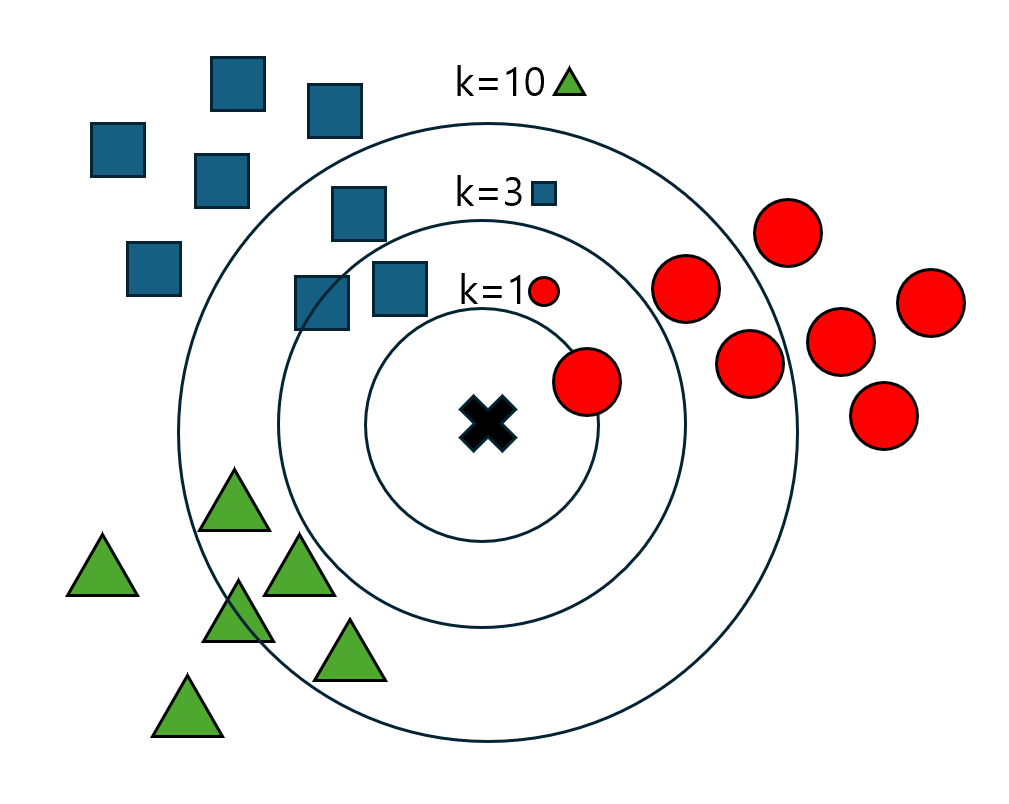

---
Your task is to:

* Iterate through odd values of k within a given range.
* For each k:
   - Run the K-NN classifier.
   - Evaluate its performance using F1-score.
* Store the F1-score for each k.
* Select the k that achieves the highest F1-score.
* Return the best k.

This process is called **hyperparameter tuning** —
we systematically search for the best setting
instead of choosing a value arbitrarily.


In [ ]:
def hyperparameter_tuning(start, end, train_vectors, labels):
    """
    Finds the optimal value of k for the K-NN classifier based on the highest F1-score.

    Args:
        start (int): The starting value of k to test.
        end (int): The ending value of k to test.
        train_vectors (np.ndarray): 2D array of BoW vectors.
        labels (np.ndarray): 1D array of ground-truth labels.

    Returns:
        int: The best performing k value (hyperparameter) found during tuning.
    """

    # =============================================================
    # TODO 8: Hyperparameter Tuning for K-NN
    # 1. Iterate through odd values of k from 'start' to 'end' (step=2)
    #    to avoid ties in majority voting.
    # 2. Run the 'knn_classifier' and calculate evaluation metrics for each k.
    # 3. Compare the current F1-score with the best F1-score found so far.
    # 4. Update 'best_k' whenever a higher F1-score is achieved.
    # =============================================================

    # <TODO>
    # YOUR CODE HERE
    raise NotImplementedError()
    # </TODO>

    return best_k

In [ ]:
# Scoring section

v_pub_tune1 = np.array([
    [1.0, 0.0], [1.1, 0.1], [0.8, -0.1],
    [0.0, 1.0], [0.1, 1.1], [-0.1, 0.8],
    [0.5, 0.4], [0.4, 0.5]
])
l_pub_tune1 = np.array([0, 0, 0, 1, 1, 1, 0, 1])
best_k1 = hyperparameter_tuning(1, 3, v_pub_tune1, l_pub_tune1)
assert best_k1 in [1, 3], f"Public Test 1 Failed: best_k({best_k1}) must be within the search range [1, 3]"

v_pub_tune2 = np.arange(40).reshape(20, 2)
l_pub_tune2 = np.array([0, 1] * 10)
start_val, end_val = 3, 7
best_k2 = hyperparameter_tuning(start_val, end_val, v_pub_tune2, l_pub_tune2)

assert best_k2 >= start_val, f"Public Test 2 Failed: best_k({best_k2}) is less than the start value({start_val})"
assert best_k2 <= end_val, f"Public Test 2 Failed: best_k({best_k2}) is greater than the end value({end_val})"
assert best_k2 % 2 != 0, f"Public Test 2 Failed: best_k({best_k2}) must be an odd number (step=2)"


# Hidden test results are hidden to ensure evaluation integrity.


### Evaluate performance with best-k

Now, let's evaluate its performance. with our best k value that we found.

In [ ]:
k_value = hyperparameter_tuning(1, 20, train_vectors, labels)
knn_preds = knn_classifier(np.array(train_vectors), np.array(labels).astype(int), k_value)
accuracy, precision, recall, f1_score = evaluate(labels, knn_preds)


print(f"--- K-NN (k={k_value}, Cosine) Results ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1_score:.4f}")

# 5. Vectorization - TF-IDF

So far, we represented sentences using Bag of Words (BoW).
However, how we represent a sentence in vector space
directly affects classification performance.

Since our classifier compares vectors using similarity metrics,
the quality of vectorization becomes extremely important.

This time, we will use a more advanced representation:
**TF-IDF (Term Frequency – Inverse Document Frequency)**.

---

BoW simply counts how many times a word appears.
But some words appear very frequently in all documents
(e.g., "the", "is", "and").

Such words are not very informative.

TF-IDF reduces the importance of words that appear in many documents,
and increases the importance of words that are rare but characteristic.


1. Term Frequency (TF)

TF measures how often a word appears in a document.

$$
TF(t, d) = \text{count of term } t \text{ in document } d
$$

2. Inverse Document Frequency (IDF)

IDF measures how rare a word is across all documents.

$$
IDF(t) = \log\left(\frac{N}{DF(t) + 1}\right) + 1
$$

- \(N\): total number of documents  
- \(DF(t)\): number of documents containing term \(t\)

The "+1" prevents division by zero (smoothing).

3. TF-IDF

Finally, we combine them:

$$
TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
$$

Words that:
- Appear frequently in one document
- But rarely across all documents

receive higher weights.

---
#### 🛑 <mark> TODO 9</mark>: Implement TF-IDF
Now, implement TF-IDF vectorization step by step.

Your task is to:

1. Build the **Term Frequency (TF) matrix**
   - Use the Bag of Words representation.
   - Each row should represent one document.
   - Each column should correspond to a word in the vocabulary.

2. Compute the **Document Frequency (DF)**
   - Count how many documents contain each word.
   - (Hint: check whether each entry is greater than 0.)

3. Compute the **Inverse Document Frequency (IDF)** using:

$$
IDF(t) = \log\left(\frac{N}{DF(t) + 1}\right) + 1
$$

4. Multiply TF and IDF element-wise
   to obtain the final TF-IDF matrix.

In [ ]:
def get_tfidf(texts, vocab):
    """
    Generates a TF-IDF matrix from a list of texts and a given vocabulary.

    Args:
        texts (list[str]): A list of sentences or messages to process.
        vocab (list[str]): The vocabulary list defining the feature space.

    Returns:
        np.ndarray: A 2D array where each row represents the TF-IDF vector of a text.
    """
    # =============================================================
    # TODO 9: Implementing TF-IDF (Term Frequency-Inverse Document Frequency)
    # 1. Create a Term Frequency (TF) matrix using Bag of Words for each text.
    # 2. Calculate Document Frequency (DF), which is the number of documents
    #    containing each word.
    # 3. Compute Inverse Document Frequency (IDF) using the smoothed formula:
    #    IDF = log(N / (DF + 1)) + 1
    # 4. Multiply TF by IDF to produce the final TF-IDF matrix.
    # =============================================================

    # <TODO>
    # YOUR CODE HERE
    raise NotImplementedError()
    # </TODO>

    return tf_idf_matrix

In [ ]:
# Scoring section

vocab_p = ['apple', 'banana']
texts_p = ["apple banana", "apple"]
res_p1 = get_tfidf(texts_p, vocab_p)
assert res_p1.shape == (2, 2), "Public Test 1 Failed: Matrix shape mismatch"
assert res_p1[0, 1] > res_p1[0, 0], "Public Test 1 Failed: 'banana' should have higher weight than 'apple' in sentence 1"

vocab_p2 = ['is']
texts_p2 = ["it is", "he is", "she is"]
res_p2 = get_tfidf(texts_p2, vocab_p2)
assert np.all(res_p2 > 0), "Public Test 2 Failed: TF-IDF values should be positive"


# Hidden test results are hidden to ensure evaluation integrity.



#### Evaluate performance with TF-IDF

So far, we used Bag of Words (BoW) vectors to classify spam messages.

Now, let’s apply the same K-NN classifier using TF-IDF vectors instead.

Will weighting words by importance improve the performance?

We will:

1. Compute TF-IDF vectors
2. Tune the best k value
3. Evaluate the final performance

Let’s compare the results with the BoW-based model.

In [ ]:
# NOTE: Executing this cell may take a few minutes.
print("Calculating TF-IDF weights...")
# Calculate TF-IDF
tf_idf_matrix = get_tfidf(texts, vocab)

# Run K-NN Classifier
print("Running K-NN Classifier (this may take a while)...")
best_k = hyperparameter_tuning(1, 20, tf_idf_matrix, labels)
knn_preds = knn_classifier(tf_idf_matrix, np.array(labels).astype(int), best_k)

accuracy, precision, recall, f1_score = evaluate(labels, knn_preds)

print("\n" + "="*30)
print("--- K-NN (TF-IDF) Evaluation ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1_score:.4f}")
print("="*30)